In [1]:
import scMPRAforge as scm
from dask.distributed import Client, LocalCluster
from pathlib import Path
import pandas as pd

2025-11-19 13:32:31.492718: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 13:32:31.496804: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [3]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")
path=DATA_ROOT/"simulated"
name="shendure_calibrated_sim_with_orthos_20251118"

In [4]:
cluster = LocalCluster(memory_limit='48G')
client = Client(cluster)

In [5]:
simu_obj=scm.de_novo_simulation.load(client,path=path,name=name)

In [6]:
ex_ground_truth=simu_obj.ground_truth

In [7]:
def load_result(root: Path, hypothesis: str, test: str, replicate: int) -> pd.DataFrame:
    """Load a TSV result from the given directory structure."""
    path = root / hypothesis / test / str(replicate)
    if not path.exists():
        raise FileNotFoundError(f"No such file: {path}")
    return pd.read_csv(path, sep='\t')

In [8]:
def merge_in_ground_truth(results,ground_truth):    
        merged=results.merge(ground_truth,
            left_on=["comparison_CRE","comparison_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"comparison_truth"},axis=1)

        #merge in `reference` ground truth
        merged=merged.merge(ground_truth,
            left_on=["reference_CRE","reference_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"reference_truth"},axis=1)

        #ground truth effect size
        merged["gt_effect_size"]=merged["comparison_truth"]/merged["reference_truth"]
        #ground truth null hypothesis that the CREs are the same : true or false?
        merged["gt_null"]=abs(merged["gt_effect_size"]-1)<1e-8

        merged["reject_null"]=merged["bh_p"]<0.05

        #godawful hack
        #merged=merged.dropna(subset=["p_value"])

        return merged

In [9]:
ground_truth=simu_obj.ground_truth

records = []

for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)
            ct = pd.crosstab(ex_merged["gt_null"], ex_merged["reject_null"])
            # Flatten the crosstab into a dict of counts
            for (gt, reject), count in ct.stack().items():
                records.append({
                    "test": test,
                    "hypothesis_set": hypothesis_set,
                    "replicate": replicate,
                    "gt_null": gt,
                    "reject_null": reject,
                    "count": count
                })

df = pd.DataFrame(records)
summary = (df.groupby(["test", "hypothesis_set", "gt_null", "reject_null"])
                ["count"]
                .agg(["mean", "std", "sum", "count"])
                .reset_index())

In [10]:
summary

,test,hypothesis_set,gt_null,reject_null,mean,std,sum,count
0,mwu,hs_all_cre,False,False,186.0,8.455767,930,5
1,mwu,hs_all_cre,False,True,1060.0,8.455767,5300,5
2,mwu,hs_all_ct,False,False,206.8,10.639549,1034,5
3,mwu,hs_all_ct,False,True,1245.2,10.639549,6226,5
4,wald,hs_all_cre,False,False,227.4,14.081903,1137,5
5,wald,hs_all_cre,False,True,1018.6,14.081903,5093,5
6,wald,hs_all_ct,False,False,202.8,8.408329,1014,5
7,wald,hs_all_ct,False,True,1249.2,8.408329,6246,5


In [11]:
records = []
for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        correct_fracs = []
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)

            # since gt_null is always False, "correct" means reject_null == True
            frac_correct = (ex_merged["reject_null"] == True).mean()
            correct_fracs.append(frac_correct)

        records.append({
            "test": test,
            "hypothesis_set": hypothesis_set,
            "mean_fraction_correct": pd.Series(correct_fracs).mean(),
            "std_fraction_correct": pd.Series(correct_fracs).std(),
        })

pd.DataFrame(records)

,test,hypothesis_set,mean_fraction_correct,std_fraction_correct
0,mwu,hs_all_cre,0.850722,0.006786
1,mwu,hs_all_ct,0.857576,0.007328
2,wald,hs_all_cre,0.817496,0.011302
3,wald,hs_all_ct,0.860331,0.005791


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_p_vs_effect(hypothesis_set, test, replicate, cell_type = None):
    ex = load_result(root=path/name/"results",
                     hypothesis=hypothesis_set,
                     test=test,
                     replicate=replicate)
    if cell_type is not None:
        ex = ex[ex['comparison_cell_type']==cell_type]

    df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

    # compute color by log10(max of comparison_truth and reference_truth)
    df["log_max_activity"] = np.log10(np.maximum(df["comparison_truth"], df["reference_truth"]).clip(lower=1e-12))

    # use a reversed warm colormap (small = red/yellow, large = blue)
    sns.scatterplot(data=df, x="gt_effect_size", y="p_value", hue="log_max_activity",
                    palette="inferno_r", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-2, 1e4)
    plt.ylim(1e1, 1e-310)

    plt.xlabel("Ground Truth Effect Size (log scale)")
    plt.ylabel("p-value (log scale)")
    plt.legend(title="log10(Max Activity)")
    plt.title(f"p-value vs Ground Truth Effect Size\n(test={test}, hypothesis_set={hypothesis_set}, replicate={replicate})")
    plt.tight_layout()
    plt.show()


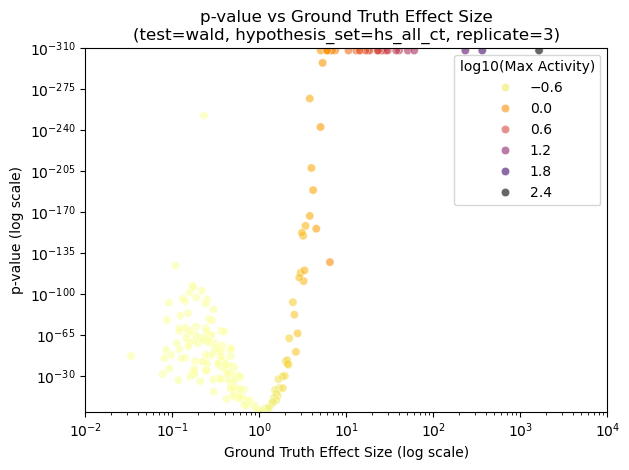

In [13]:
plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate='3', cell_type = 'reference')

In [14]:
ex.comparison_cell_type.unique()

array(['Cardiomyocytes', 'EpiblastPrimitiveStreak', 'ExEndodermParietal',
       'ExEndodermVisceral', 'Haematoendothelial', 'Mesoderm',
       'NeuroectodermBrain', 'NeuroectodermRostral', 'SurfaceEctoderm',
       'reference'], dtype=object)

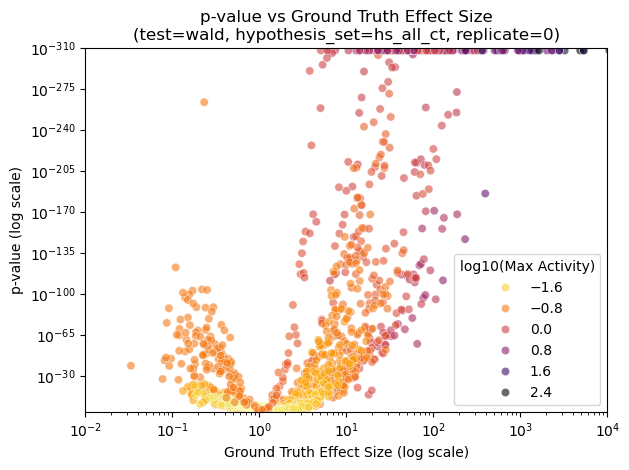

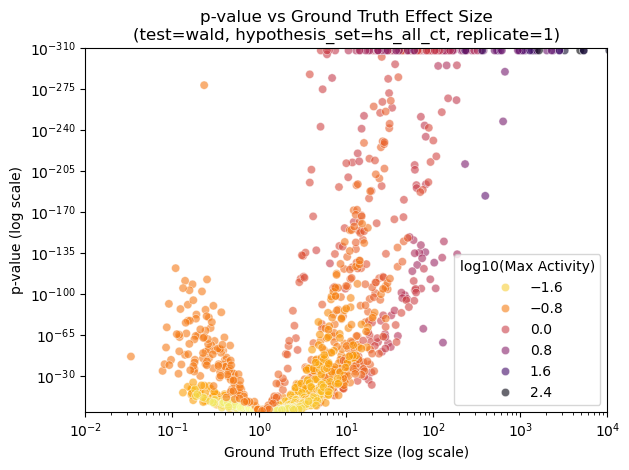

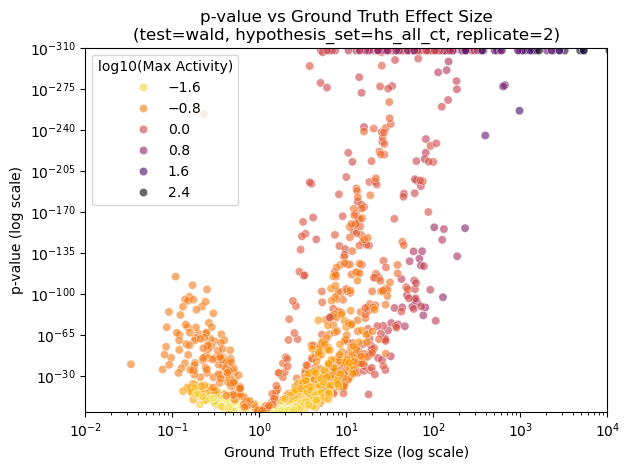

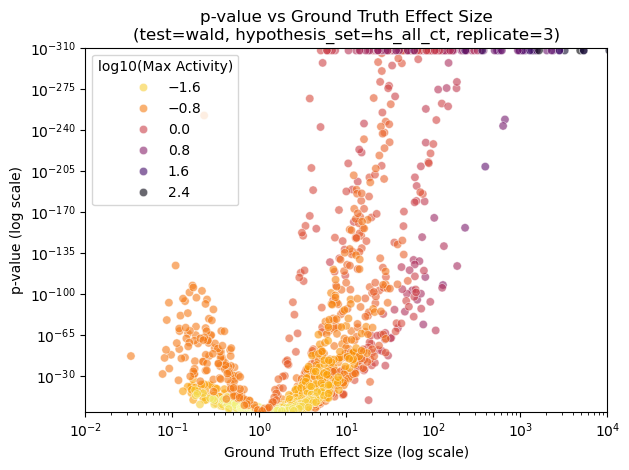

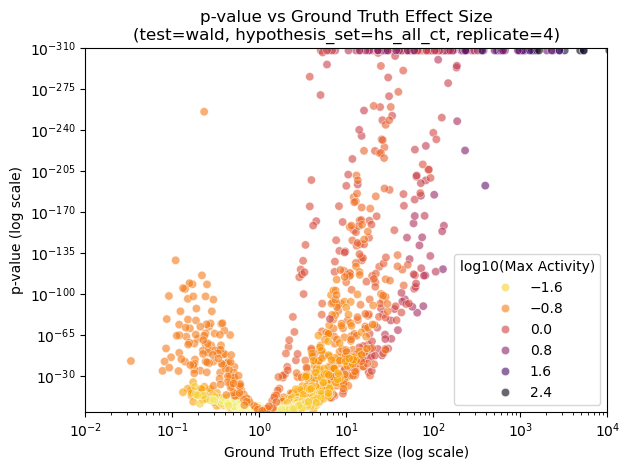

In [15]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate=replicate)

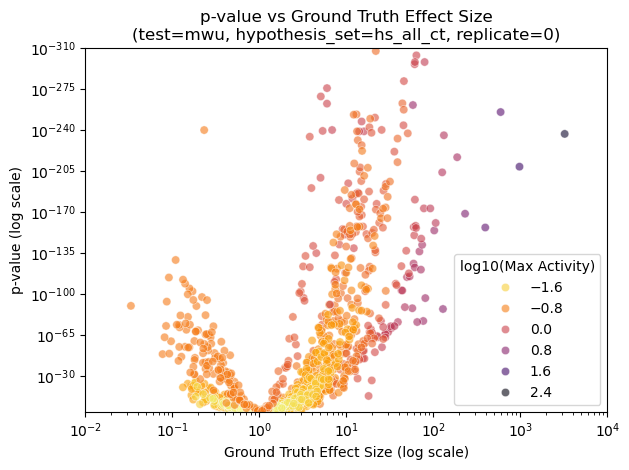

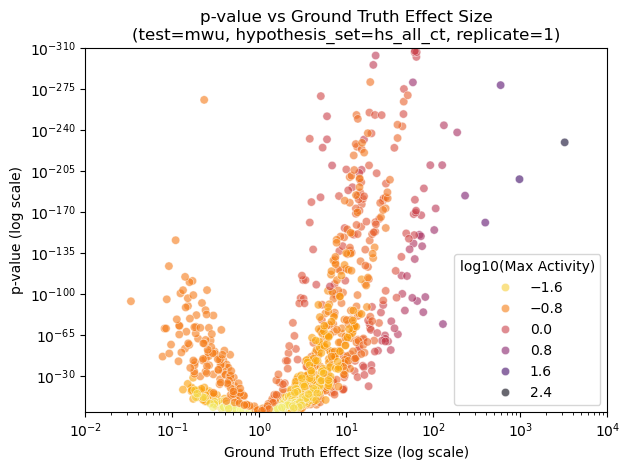

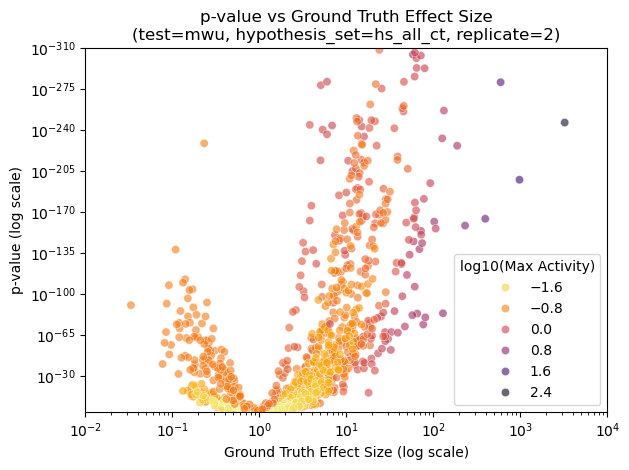

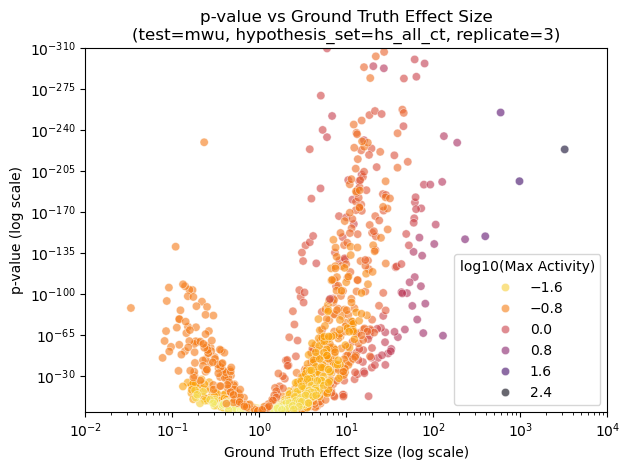

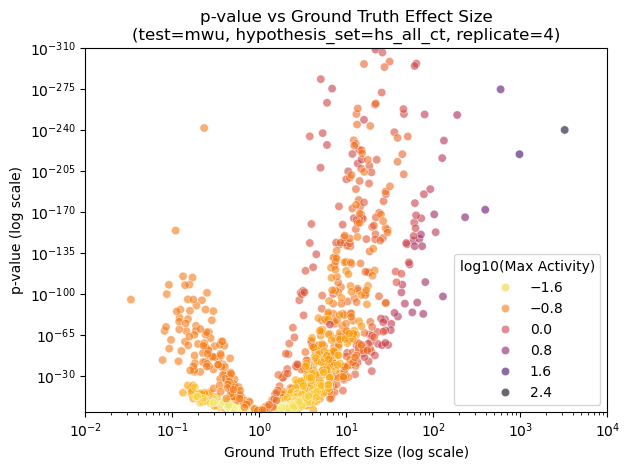

In [16]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="mwu",replicate=replicate)

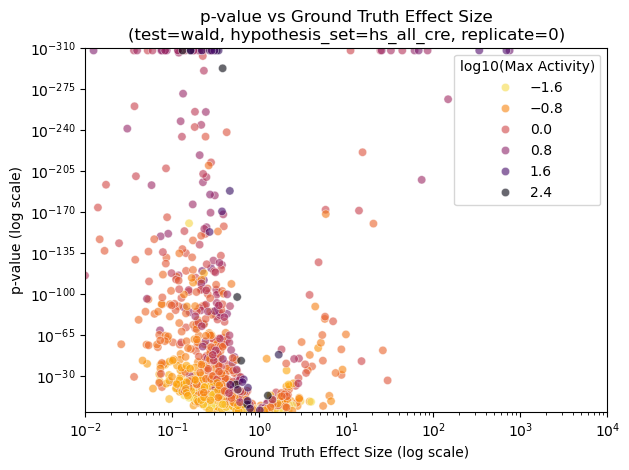

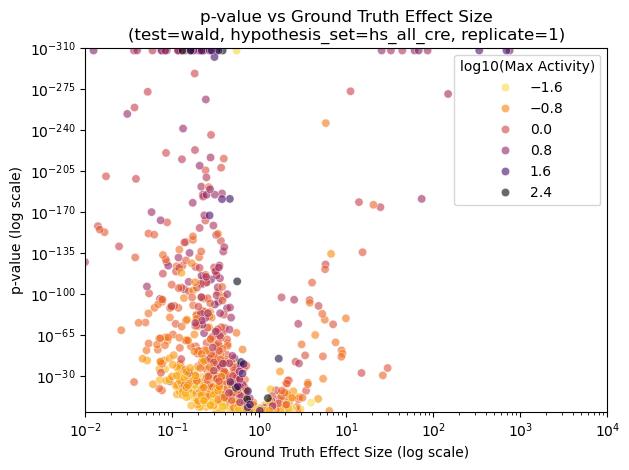

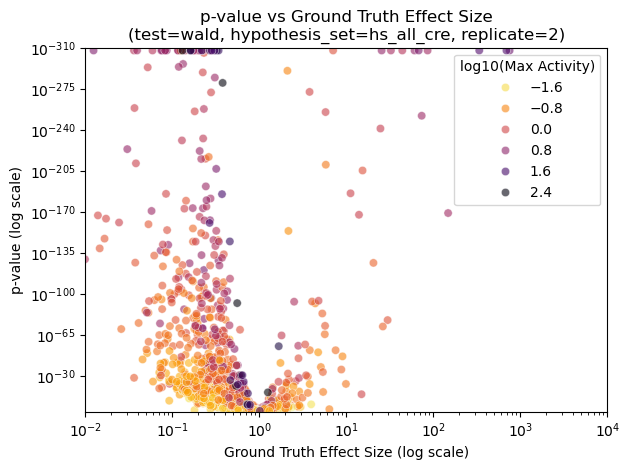

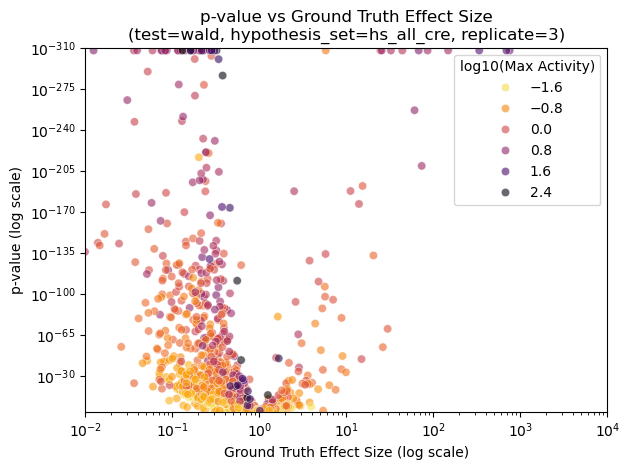

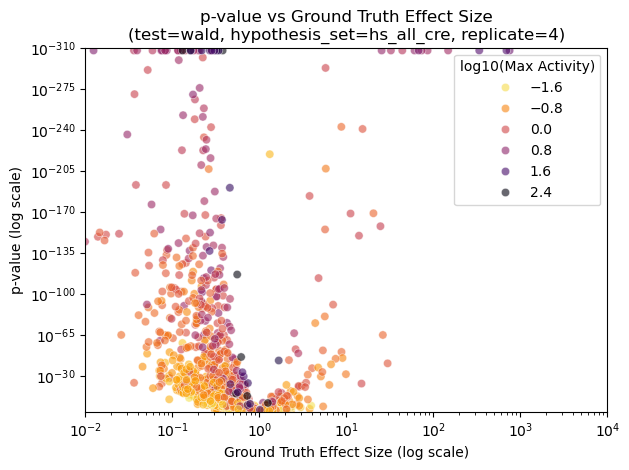

In [17]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="wald",replicate=replicate)

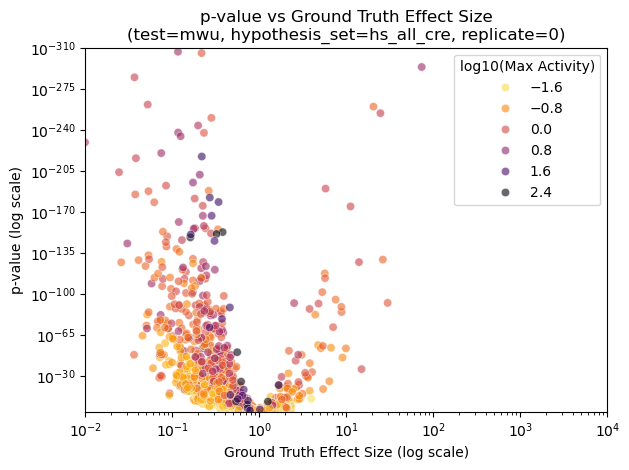

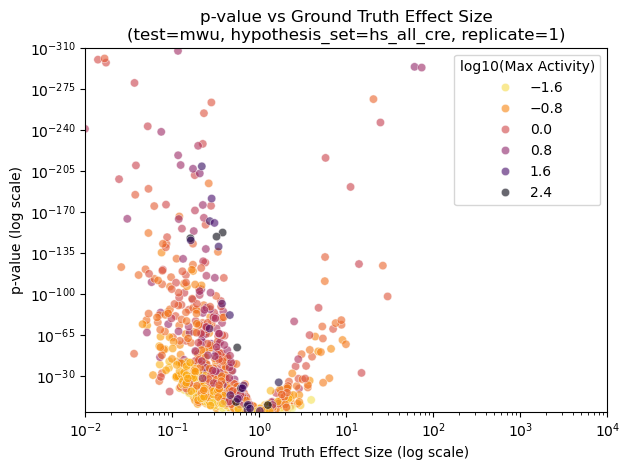

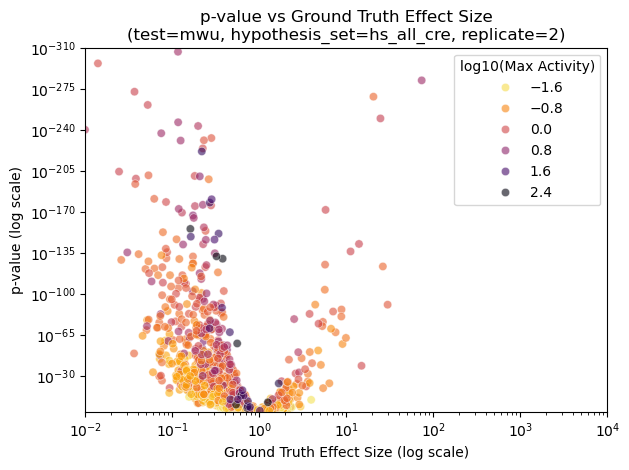

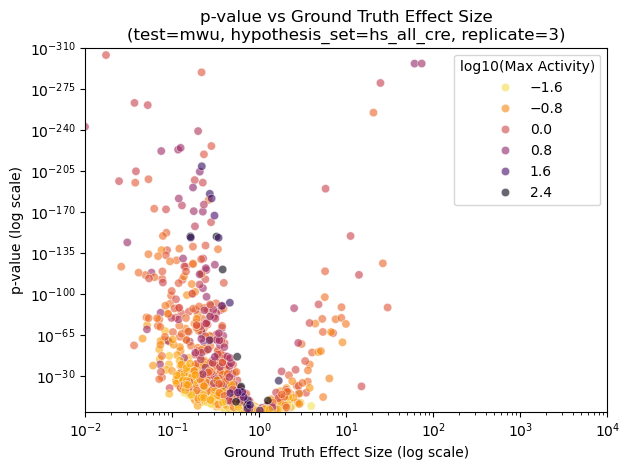

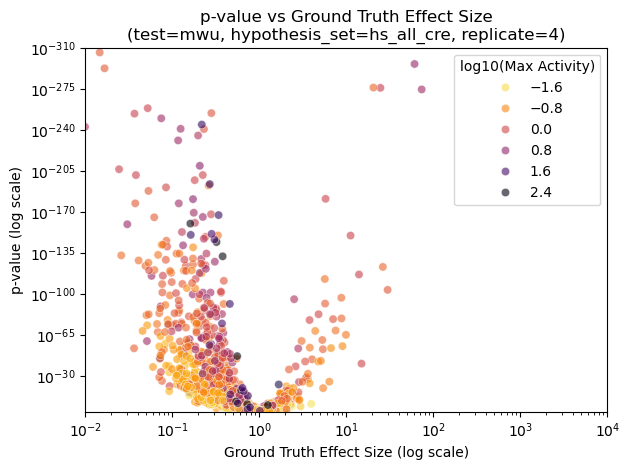

In [18]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="mwu",replicate=replicate)

In [33]:
ex = load_result(root=path/name/"results",
                     hypothesis="hs_all_cre",
                     test="wald",
                     replicate=0)
df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

In [34]:
df[df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
65,Btg1_chr10_9593,ExEndodermParietal,Btg1_chr10_9593,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for ExEndodermParietal,wald,1.0,0.097791,0.079216,1.234489,False,False
68,Btg1_chr10_9593,Mesoderm,Btg1_chr10_9593,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for Mesoderm,wald,1.0,0.067904,0.079216,0.857201,False,False
106,Cdk5r1_chr11_12575,ExEndodermParietal,Cdk5r1_chr11_12575,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for ExEndodermParietal,wald,1.0,0.044369,0.096217,0.461132,False,False
121,Cdk5r1_chr11_12590,EpiblastPrimitiveStreak,Cdk5r1_chr11_12590,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for EpiblastPrimitiveStreak,wald,1.0,0.043316,0.043588,0.993761,False,False
128,Cited2_chr10_1246,ExEndodermVisceral,Cited2_chr10_1246,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for ExEndodermVisceral,wald,1.0,0.062173,0.026808,2.319228,False,False
149,Cited2_chr10_1267,ExEndodermParietal,Cited2_chr10_1267,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for ExEndodermParietal,wald,1.0,0.048193,0.040128,1.200971,False,False
162,Col1a1_chr11_15259,EpiblastPrimitiveStreak,Col1a1_chr11_15259,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for EpiblastPrimitiveStreak,wald,1.0,0.057826,0.086297,0.670080,False,False
163,Col1a1_chr11_15259,ExEndodermParietal,Col1a1_chr11_15259,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for ExEndodermParietal,wald,1.0,0.074679,0.086297,0.865381,False,False
165,Col1a1_chr11_15259,Haematoendothelial,Col1a1_chr11_15259,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for Haematoendothelial,wald,1.0,0.071342,0.086297,0.826711,False,False
166,Col1a1_chr11_15259,Mesoderm,Col1a1_chr11_15259,reference,cell_specificity,NaN,NaN,NaN,False,ok; se==0 for Mesoderm,wald,1.0,0.071669,0.086297,0.830500,False,False


In [47]:
ex2 = load_result(root=path/name/"results",
                     hypothesis="hs_all_cre",
                     test="wald",
                     replicate=1)
df2 = merge_in_ground_truth(results=ex2, ground_truth=ex_ground_truth)

In [48]:
df2[df2.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
846,Sox17_chr1_60,ExEndodermParietal,Sox17_chr1_60,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.005472,0.05909,0.0926,False,False
1189,Txndc12_chr4_7969,ExEndodermParietal,Txndc12_chr4_7969,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.154256,0.00000,inf,False,False


In [20]:
client.close()
cluster.close()